In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/Menstural_cyclelength.csv')
display(df.head())

,new_id,age,cycle_number,cycle_start_date,cycle_end_date,cycle_length,conception_cycle
0,1,26,1,5/21/03,6/16/03,27.0,No
1,1,26,2,6/17/03,7/15/03,29.0,No
2,1,26,3,7/16/03,8/13/03,NaN,Yes
3,2,28,2,6/9/03,7/5/03,27.0,No
4,2,28,3,7/6/03,8/9/03,NaN,Yes


In [4]:
display(df.describe())

,new_id,age,cycle_number,cycle_length
count,3324.000000,3324.000000,3324.000000,3144.000000
mean,293.789410,27.247894,6.333333,30.331425
std,160.745226,4.316675,3.930202,6.738482
min,1.000000,18.000000,1.000000,15.000000
25%,153.000000,24.000000,3.000000,27.000000
50%,287.000000,27.000000,6.000000,29.000000
75%,434.000000,30.000000,9.000000,32.000000
max,581.000000,40.000000,26.000000,98.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3324 entries, 0 to 3323
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   new_id            3324 non-null   int64  
 1   age               3324 non-null   int64  
 2   cycle_number      3324 non-null   int64  
 3   cycle_start_date  3324 non-null   object 
 4   cycle_end_date    3324 non-null   object 
 5   cycle_length      3144 non-null   float64
 6   conception_cycle  3324 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 181.9+ KB


In [6]:
print('Null values in each column:')
display(df.isnull().sum())

Null values in each column:


,0
new_id,0
age,0
cycle_number,0
cycle_start_date,0
cycle_end_date,0
cycle_length,180
conception_cycle,0


In [7]:
# Convert date columns to datetime objects
df['cycle_start_date'] = pd.to_datetime(df['cycle_start_date'])
df['cycle_end_date'] = pd.to_datetime(df['cycle_end_date'])

# Calculate cycle_length based on start and end dates
df['calculated_cycle_length'] = (df['cycle_end_date'] - df['cycle_start_date']).dt.days + 1

/tmp/ipykernel_4246/1155600813.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['cycle_start_date'] = pd.to_datetime(df['cycle_start_date'])
/tmp/ipykernel_4246/1155600813.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['cycle_end_date'] = pd.to_datetime(df['cycle_end_date'])


In [11]:
# Fill missing 'cycle_length' values with the calculated values
df['cycle_length'] = df['cycle_length'].fillna(df['calculated_cycle_length'])

# Verify if missing values have been filled
missing_cycle_length_after_fill = df['cycle_length'].isnull().sum()
print(f"Number of missing values in 'cycle_length' column after filling: {missing_cycle_length_after_fill}")

# Display the updated DataFrame head to show the changes
display(df.head(20))

Number of missing values in 'cycle_length' column after filling: 0


,new_id,age,cycle_number,cycle_start_date,cycle_end_date,cycle_length,conception_cycle,calculated_cycle_length,year,month,day,day_of_week
0,1,26,1,2003-05-21,2003-06-16,27.0,No,27,2003,5,21,2
1,1,26,2,2003-06-17,2003-07-15,29.0,No,29,2003,6,17,1
2,1,26,3,2003-07-16,2003-08-13,29.0,Yes,29,2003,7,16,2
3,2,28,2,2003-06-09,2003-07-05,27.0,No,27,2003,6,9,0
4,2,28,3,2003-07-06,2003-08-09,35.0,Yes,35,2003,7,6,6
5,3,28,1,2003-06-08,2003-07-02,25.0,No,25,2003,6,8,6
6,3,28,2,2003-07-03,2003-07-28,26.0,No,26,2003,7,3,3
7,3,28,3,2003-07-29,2003-08-24,27.0,No,27,2003,7,29,1
8,3,28,4,2003-08-25,2003-09-22,29.0,Yes,29,2003,8,25,0
9,4,33,1,2003-06-19,2003-07-14,26.0,No,26,2003,6,19,3


In [9]:
# Sort data by new_id and cycle_start_date to ensure correct time series order
df = df.sort_values(by=['new_id', 'cycle_start_date']).reset_index(drop=True)

# Extract time-based features from cycle_start_date
df['year'] = df['cycle_start_date'].dt.year
df['month'] = df['cycle_start_date'].dt.month
df['day'] = df['cycle_start_date'].dt.day
df['day_of_week'] = df['cycle_start_date'].dt.dayofweek # Monday=0, Sunday=6

display(df.head())

,new_id,age,cycle_number,cycle_start_date,cycle_end_date,cycle_length,conception_cycle,calculated_cycle_length,year,month,day,day_of_week
0,1,26,1,2003-05-21,2003-06-16,27.0,No,27,2003,5,21,2
1,1,26,2,2003-06-17,2003-07-15,29.0,No,29,2003,6,17,1
2,1,26,3,2003-07-16,2003-08-13,29.0,Yes,29,2003,7,16,2
3,2,28,2,2003-06-09,2003-07-05,27.0,No,27,2003,6,9,0
4,2,28,3,2003-07-06,2003-08-09,35.0,Yes,35,2003,7,6,6


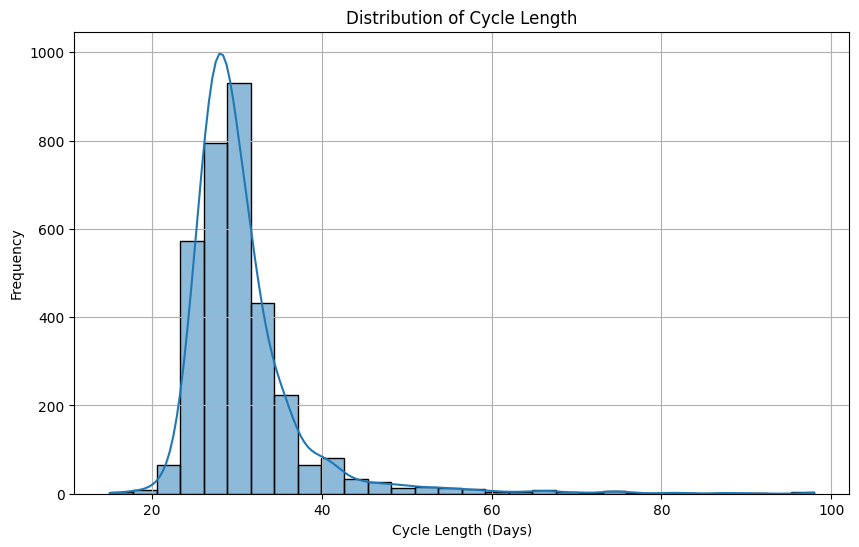

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['cycle_length'], bins=30, kde=True)
plt.title('Distribution of Cycle Length')
plt.xlabel('Cycle Length (Days)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## Data Preparation for Model Training

### 1. Data Cleaning & Temporal Alignment

First, we'll ensure our dates are correctly formatted and the dataset is sorted chronologically per user. We will also derive `next_cycle_start_date` for potential use, although `cycle_length` is our primary target. Note: `cycle_start_date` and `cycle_end_date` are already converted to datetime objects, and the data is already sorted by `new_id` and `cycle_start_date` from previous steps.

In [23]:
# Derive 'next_cycle_start_date' for each user, which is the 'cycle_start_date' of their next cycle.
df['next_cycle_start_date'] = df.groupby('new_id')['cycle_start_date'].shift(-1)

# Display head to check the new column
display(df.head())

,new_id,age,cycle_number,cycle_start_date,cycle_end_date,cycle_length,conception_cycle,calculated_cycle_length,year,month,day,day_of_week,conception_cycle_encoded,next_cycle_start_date,prev_cycle_len_1,prev_cycle_len_2,user_running_mean,user_running_std
0,1,26,1,2003-05-21,2003-06-16,27.0,No,27,2003,5,21,2,0,2003-06-17,NaN,NaN,27.000000,0.000000
1,1,26,2,2003-06-17,2003-07-15,29.0,No,29,2003,6,17,1,0,2003-07-16,27.0,NaN,28.000000,1.414214
2,1,26,3,2003-07-16,2003-08-13,29.0,Yes,29,2003,7,16,2,1,NaT,29.0,27.0,28.333333,1.154701
3,2,28,2,2003-06-09,2003-07-05,27.0,No,27,2003,6,9,0,0,2003-07-06,NaN,NaN,27.000000,0.000000
4,2,28,3,2003-07-06,2003-08-09,35.0,Yes,35,2003,7,6,6,1,NaT,27.0,NaN,31.000000,5.656854


### 2. Feature Engineering (Biological & Lagged Memory)

Now, we will create predictive features based on historical cycle data for each user.

In [24]:
# Create lag features for cycle_length
# 'prev_cycle_len_1': Cycle length of the previous cycle
# 'prev_cycle_len_2': Cycle length of the second previous cycle
df['prev_cycle_len_1'] = df.groupby('new_id')['cycle_length'].shift(1)
df['prev_cycle_len_2'] = df.groupby('new_id')['cycle_length'].shift(2)

# 'prev_period_len_1': The prompt mentions this, but 'Period Length' column is not in the dataset.
# We will skip creating this feature as the raw data does not contain 'Period Length'.
# If this feature is critical, please provide the 'Period Length' data or a method to derive it.

# Calculate expanding/cumulative mean and standard deviation of cycle lengths per user
df['user_running_mean'] = df.groupby('new_id')['cycle_length'].expanding().mean().reset_index(level=0, drop=True)
# Fill early missing std values with 0 (for the first cycle where std is not applicable)
df['user_running_std'] = df.groupby('new_id')['cycle_length'].expanding().std().reset_index(level=0, drop=True).fillna(0)

# 'start_month': Already extracted as 'month' in a previous step.

display(df.head())

,new_id,age,cycle_number,cycle_start_date,cycle_end_date,cycle_length,conception_cycle,calculated_cycle_length,year,month,day,day_of_week,conception_cycle_encoded,next_cycle_start_date,prev_cycle_len_1,prev_cycle_len_2,user_running_mean,user_running_std
0,1,26,1,2003-05-21,2003-06-16,27.0,No,27,2003,5,21,2,0,2003-06-17,NaN,NaN,27.000000,0.000000
1,1,26,2,2003-06-17,2003-07-15,29.0,No,29,2003,6,17,1,0,2003-07-16,27.0,NaN,28.000000,1.414214
2,1,26,3,2003-07-16,2003-08-13,29.0,Yes,29,2003,7,16,2,1,NaT,29.0,27.0,28.333333,1.154701
3,2,28,2,2003-06-09,2003-07-05,27.0,No,27,2003,6,9,0,0,2003-07-06,NaN,NaN,27.000000,0.000000
4,2,28,3,2003-07-06,2003-08-09,35.0,Yes,35,2003,7,6,6,1,NaT,27.0,NaN,31.000000,5.656854


## Data Preparation for Model Training

### 1. Data Cleaning & Temporal Alignment

First, we'll ensure our dates are correctly formatted and the dataset is sorted chronologically per user. We will also derive `next_cycle_start_date` for potential use, although `cycle_length` is our primary target. Note: `cycle_start_date` and `cycle_end_date` are already converted to datetime objects, and the data is already sorted by `new_id` and `cycle_start_date` from previous steps.

In [17]:
# Derive 'next_cycle_start_date' for each user, which is the 'cycle_start_date' of their next cycle.
df['next_cycle_start_date'] = df.groupby('new_id')['cycle_start_date'].shift(-1)

# Display head to check the new column
display(df.head())

,new_id,age,cycle_number,cycle_start_date,cycle_end_date,cycle_length,conception_cycle,calculated_cycle_length,year,month,day,day_of_week,conception_cycle_encoded,next_cycle_start_date
0,1,26,1,2003-05-21,2003-06-16,27.0,No,27,2003,5,21,2,1,2003-06-17
1,1,26,2,2003-06-17,2003-07-15,29.0,No,29,2003,6,17,1,1,2003-07-16
2,1,26,3,2003-07-16,2003-08-13,29.0,Yes,29,2003,7,16,2,2,NaT
3,2,28,2,2003-06-09,2003-07-05,27.0,No,27,2003,6,9,0,1,2003-07-06
4,2,28,3,2003-07-06,2003-08-09,35.0,Yes,35,2003,7,6,6,2,NaT


### 2. Feature Engineering (Biological & Lagged Memory)

Now, we will create predictive features based on historical cycle data for each user.

In [18]:
# Create lag features for cycle_length
# 'prev_cycle_len_1': Cycle length of the previous cycle
# 'prev_cycle_len_2': Cycle length of the second previous cycle
df['prev_cycle_len_1'] = df.groupby('new_id')['cycle_length'].shift(1)
df['prev_cycle_len_2'] = df.groupby('new_id')['cycle_length'].shift(2)

# 'prev_period_len_1': The prompt mentions this, but 'Period Length' column is not in the dataset.
# We will skip creating this feature as the raw data does not contain 'Period Length'.
# If this feature is critical, please provide the 'Period Length' data or a method to derive it.

# Calculate expanding/cumulative mean and standard deviation of cycle lengths per user
df['user_running_mean'] = df.groupby('new_id')['cycle_length'].expanding().mean().reset_index(level=0, drop=True)
# Fill early missing std values with 0 (for the first cycle where std is not applicable)
df['user_running_std'] = df.groupby('new_id')['cycle_length'].expanding().std().reset_index(level=0, drop=True).fillna(0)

# 'start_month': Already extracted as 'month' in a previous step.

display(df.head())

,new_id,age,cycle_number,cycle_start_date,cycle_end_date,cycle_length,conception_cycle,calculated_cycle_length,year,month,day,day_of_week,conception_cycle_encoded,next_cycle_start_date,prev_cycle_len_1,prev_cycle_len_2,user_running_mean,user_running_std
0,1,26,1,2003-05-21,2003-06-16,27.0,No,27,2003,5,21,2,1,2003-06-17,NaN,NaN,27.000000,0.000000
1,1,26,2,2003-06-17,2003-07-15,29.0,No,29,2003,6,17,1,1,2003-07-16,27.0,NaN,28.000000,1.414214
2,1,26,3,2003-07-16,2003-08-13,29.0,Yes,29,2003,7,16,2,2,NaT,29.0,27.0,28.333333,1.154701
3,2,28,2,2003-06-09,2003-07-05,27.0,No,27,2003,6,9,0,1,2003-07-06,NaN,NaN,27.000000,0.000000
4,2,28,3,2003-07-06,2003-08-09,35.0,Yes,35,2003,7,6,6,2,NaT,27.0,NaN,31.000000,5.656854


## Predicting 'conception_cycle' with XGBoost

This section will prepare the data and train an XGBoost model to predict the binary target `conception_cycle`.

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Label Encoding for Target Variable

We will convert the 'Yes'/'No' labels in `conception_cycle` to numerical 1/0.

In [19]:
# Filter out rows where 'conception_cycle' is 'Missing'
df = df[df['conception_cycle'] != 'Missing'].reset_index(drop=True)

# Re-apply Label Encoding for target variable: 'No' -> 0, 'Yes' -> 1
le = LabelEncoder()
df['conception_cycle_encoded'] = le.fit_transform(df['conception_cycle'])

print(f"Original 'conception_cycle' categories after filtering: {le.classes_}")
print(f"Encoded 'conception_cycle' categories: {le.transform(le.classes_)}")

display(df[['conception_cycle', 'conception_cycle_encoded']].head())

Original 'conception_cycle' categories after filtering: ['No' 'Yes']
Encoded 'conception_cycle' categories: [0 1]


,conception_cycle,conception_cycle_encoded
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


### 2. Feature Selection and Data Preparation

We will select relevant features, dropping redundant columns like `calculated_cycle_length` and the raw date strings. The `new_id` column will be used for GroupKFold and then dropped from the feature set itself.

In [20]:
# Define features (X) and target (y)
# Drop 'new_id', 'cycle_start_date', 'cycle_end_date', 'conception_cycle', 'calculated_cycle_length'
# 'month', 'day', 'year', 'day_of_week' are already numeric features extracted from dates.
# 'next_cycle_start_date' is also dropped to prevent data leakage.

features = [
    'age',
    'cycle_number',
    'cycle_length',
    'year',
    'month',
    'day',
    'day_of_week',
    'prev_cycle_len_1',
    'prev_cycle_len_2',
    'user_running_mean',
    'user_running_std'
]

X = df[features]
y = df['conception_cycle_encoded']
groups = df['new_id']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Groups (new_id) shape: {groups.shape}")

Features (X) shape: (3317, 11)
Target (y) shape: (3317,)
Groups (new_id) shape: (3317,)


### 3. Handling Missing Values

We will drop rows with NaN values, which were introduced by the lag features at the beginning of each user's data. This step is crucial before training the model.

In [21]:
initial_rows = df.shape[0]
df_cleaned = df.dropna(subset=features + ['conception_cycle_encoded', 'new_id'])

X_cleaned = df_cleaned[features]
y_cleaned = df_cleaned['conception_cycle_encoded']
groups_cleaned = df_cleaned['new_id']

print(f"Original number of rows: {initial_rows}")
print(f"Number of rows after dropping NaNs: {df_cleaned.shape[0]}")
print(f"Number of rows dropped: {initial_rows - df_cleaned.shape[0]}")

print(f"Cleaned Features (X_cleaned) shape: {X_cleaned.shape}")
print(f"Cleaned Target (y_cleaned) shape: {y_cleaned.shape}")
print(f"Cleaned Groups (groups_cleaned) shape: {groups_cleaned.shape}")

Original number of rows: 3317
Number of rows after dropping NaNs: 2227
Number of rows dropped: 1090
Cleaned Features (X_cleaned) shape: (2227, 11)
Cleaned Target (y_cleaned) shape: (2227,)
Cleaned Groups (groups_cleaned) shape: (2227,)


### 4. GroupKFold Validation and XGBoost Training

We will use `GroupKFold` to split the data, ensuring that all cycles from a single `new_id` (user) are either in the training or testing set, preventing data leakage. An XGBoost classifier will be trained and evaluated within each fold.

In [22]:
n_splits = 5 # Number of folds
gkf = GroupKFold(n_splits=n_splits)

# Initialize lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# Loop through each fold
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cleaned, y_cleaned, groups_cleaned)):
    X_train, X_test = X_cleaned.iloc[train_idx], X_cleaned.iloc[test_idx]
    y_train, y_test = y_cleaned.iloc[train_idx], y_cleaned.iloc[test_idx]

    # Initialize and train XGBoost Classifier
    xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_model.fit(X_train, y_train)

    # Make predictions
    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))
    roc_auc_scores.append(roc_auc_score(y_test, y_pred_proba))

    print(f"--- Fold {fold+1}/{n_splits} ---")
    print(f"Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"Precision: {precision_scores[-1]:.4f}")
    print(f"Recall: {recall_scores[-1]:.4f}")
    print(f"F1-Score: {f1_scores[-1]:.4f}")
    print(f"ROC-AUC: {roc_auc_scores[-1]:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\n")

# Print average metrics across all folds
print("=== Average Metrics Across Folds ===")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} +/- {np.std(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f} +/- {np.std(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f} +/- {np.std(recall_scores):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}")
print(f"Average ROC-AUC: {np.mean(roc_auc_scores):.4f} +/- {np.std(roc_auc_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:53:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Fold 1/5 ---
Accuracy: 0.9439
Precision: 0.6667
Recall: 0.2143
F1-Score: 0.3243
ROC-AUC: 0.7648
Confusion Matrix:
 [[415   3]
 [ 22   6]]


--- Fold 2/5 ---
Accuracy: 0.9283
Precision: 0.3333
Recall: 0.1429
F1-Score: 0.2000
ROC-AUC: 0.8742
Confusion Matrix:
 [[410   8]
 [ 24   4]]




/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:53:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:53:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Fold 3/5 ---
Accuracy: 0.9528
Precision: 0.6667
Recall: 0.3200
F1-Score: 0.4324
ROC-AUC: 0.8955
Confusion Matrix:
 [[416   4]
 [ 17   8]]


--- Fold 4/5 ---
Accuracy: 0.9371
Precision: 0.5000
Recall: 0.1429
F1-Score: 0.2222
ROC-AUC: 0.7862
Confusion Matrix:
 [[413   4]
 [ 24   4]]


--- Fold 5/5 ---
Accuracy: 0.9371
Precision: 0.1875
Recall: 0.1667
F1-Score: 0.1765
ROC-AUC: 0.7950
Confusion Matrix:
 [[414  13]
 [ 15   3]]


=== Average Metrics Across Folds ===
Average Accuracy: 0.9398 +/- 0.0082
Average Precision: 0.4708 +/- 0.1880
Average Recall: 0.1973 +/- 0.0666
Average F1-Score: 0.2711 +/- 0.0951
Average ROC-AUC: 0.8231 +/- 0.0518


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:53:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:53:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Cycle Length Regression with Tree Models and LSTM

Now we will prepare the data and train models to predict `cycle_length`.

### 1. Target Scaling and Data Preparation for Regression

We will log-transform the `cycle_length` target variable to help tree models cope with sudden, irregular cycle spikes. We will reuse the `df_cleaned` DataFrame which already has the engineered features and dropped NaNs.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define features (X) and target (y) for regression
features_regression = [
    'age',
    'cycle_number',
    'year',
    'month',
    'day',
    'day_of_week',
    'prev_cycle_len_1',
    'prev_cycle_len_2',
    'user_running_mean',
    'user_running_std'
]

X_reg = df_cleaned[features_regression]
y_reg = df_cleaned['cycle_length']
# groups_reg = df_cleaned['new_id'] # Keep groups for potential future use or consistency

# Apply log-transformation to the target variable
y_reg_transformed = np.log1p(y_reg)

print(f"Features (X_reg) shape: {X_reg.shape}")
print(f"Target (y_reg_transformed) shape: {y_reg_transformed.shape}")
# print(f"Groups (groups_reg) shape: {groups_reg.shape}")

display(y_reg_transformed.head())

Features (X_reg) shape: (2227, 10)
Target (y_reg_transformed) shape: (2227,)


,cycle_length
2,3.401197
7,3.332205
8,3.401197
11,3.433987
12,3.332205


### 2. Random Forest Regression (Format A)

We will train a Random Forest Regressor using a standard train-test split for demonstration, keeping in mind the GroupKFold is preferred for robustness.

In [32]:
# Using a simple train-test split for now, but GroupKFold is recommended
# Note: stratify with continuous target is not straightforward, skipping 'groups_reg' for stratify here.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = \
    train_test_split(X_reg, y_reg_transformed, test_size=0.2, random_state=42)

# Initialize and train Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions and inverse transform
y_pred_rf_transformed = rf_reg_model.predict(X_test_reg)
y_pred_rf = np.expm1(y_pred_rf_transformed)
y_test_original = np.expm1(y_test_reg)

# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test_original, y_pred_rf))
mae_rf = mean_absolute_error(y_test_original, y_pred_rf)
r2_rf = r2_score(y_test_original, y_pred_rf)

print("--- Random Forest Regression --- ")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")

--- Random Forest Regression --- 
RMSE: 4.62
MAE: 2.33
R-squared: 0.55


### 3. XGBoost Regression (Format A)

Next, we'll train an XGBoost Regressor for cycle length prediction.

In [33]:
# Initialize and train XGBoost Regressor
xgb_reg_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions and inverse transform
y_pred_xgb_transformed = xgb_reg_model.predict(X_test_reg)
y_pred_xgb = np.expm1(y_pred_xgb_transformed)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test_original, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_original, y_pred_xgb)
r2_xgb = r2_score(y_test_original, y_pred_xgb)

print("--- XGBoost Regression --- ")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R-squared: {r2_xgb:.2f}")

--- XGBoost Regression --- 
RMSE: 5.33
MAE: 2.45
R-squared: 0.40


### 4. LSTM Networks Data Preparation (Format B)

For LSTM networks, we need to reshape the data into a 3D NumPy tensor with `(samples, lookback_steps, features)`. We will ensure sequences do not cross user boundaries.

First, we need to scale the numerical features for optimal LSTM performance.

In [37]:
from sklearn.preprocessing import MinMaxScaler

# Prepare features for scaling (exclude 'new_id' and the target 'cycle_length' itself)
features_for_scaling = [
    'age',
    'cycle_number',
    'year',
    'month',
    'day',
    'day_of_week',
    'prev_cycle_len_1',
    'prev_cycle_len_2',
    'user_running_mean',
    'user_running_std'
]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cleaned[features_for_scaling])

# Convert back to DataFrame to maintain structure for sequence generation
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_scaling, index=df_cleaned.index)

y_lstm = y_reg_transformed.values # Use the log-transformed target
groups_lstm = df_cleaned['new_id'].values

print(f"Scaled features shape: {X_scaled_df.shape}")
print(f"Target for LSTM shape: {y_lstm.shape}")

Scaled features shape: (2227, 10)
Target for LSTM shape: (2227,)


In [38]:
def create_sequences(X, y, groups, lookback_steps):
    X_sequences, y_sequences, group_sequences = [], [], []
    unique_groups = np.unique(groups)

    for group_id in unique_groups:
        group_indices = np.where(groups == group_id)[0]

        # Ensure the group has enough data for at least one sequence
        if len(group_indices) < lookback_steps + 1: # Need lookback_steps for features + 1 for target
            continue

        X_group = X.iloc[group_indices] # Use iloc for DataFrame indexing
        y_group = y[group_indices]

        for i in range(len(X_group) - lookback_steps):
            # Features are the 'lookback_steps' previous cycles
            X_sequences.append(X_group.iloc[i:(i + lookback_steps)].values)
            # Target is the cycle_length of the current cycle (after the lookback)
            y_sequences.append(y_group[i + lookback_steps])
            group_sequences.append(group_id)

    return np.array(X_sequences), np.array(y_sequences), np.array(group_sequences)

lookback_steps = 2 # As per request for 'prev_cycle_len_1' and 'prev_cycle_len_2'

X_lstm, y_lstm_target, groups_lstm_seq = create_sequences(X_scaled_df, y_lstm, groups_lstm, lookback_steps)

print(f"X_lstm shape: {X_lstm.shape} (samples, lookback_steps, features)")
print(f"y_lstm_target shape: {y_lstm_target.shape}")
print(f"groups_lstm_seq shape: {groups_lstm_seq.shape}")

X_lstm shape: (1410, 2, 10) (samples, lookback_steps, features)
y_lstm_target shape: (1410,)
groups_lstm_seq shape: (1410,)


### 5. Split and Shape for LSTM Models

Now we perform a train-test split for the LSTM data, again ensuring no user data crosses the split boundary.

In [39]:
from sklearn.model_selection import GroupKFold

# Using GroupKFold to ensure user integrity during split for LSTM data
gkf_lstm = GroupKFold(n_splits=5) # Using 5 splits as a common practice

# Get one train/test split from GroupKFold (for demonstration, a full cross-validation would be more robust)
for train_idx, test_idx in gkf_lstm.split(X_lstm, y_lstm_target, groups_lstm_seq):
    X_train_lstm, X_test_lstm = X_lstm[train_idx], X_lstm[test_idx]
    y_train_lstm, y_test_lstm = y_lstm_target[train_idx], y_lstm_target[test_idx]
    # We don't need groups_train_lstm, groups_test_lstm for actual model training after the split
    break # Take only the first split for this example

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

X_train_lstm shape: (1128, 2, 10)
y_train_lstm shape: (1128,)
X_test_lstm shape: (282, 2, 10)
y_test_lstm shape: (282,)


### 4. LSTM Networks Data Preparation (Format B)

For LSTM networks, we need to reshape the data into a 3D NumPy tensor with `(samples, lookback_steps, features)`. We will ensure sequences do not cross user boundaries.

First, we need to scale the numerical features for optimal LSTM performance.

In [34]:
from sklearn.preprocessing import MinMaxScaler

# Prepare features for scaling (exclude 'new_id' and the target 'cycle_length' itself)
features_for_scaling = [
    'age',
    'cycle_number',
    'year',
    'month',
    'day',
    'day_of_week',
    'prev_cycle_len_1',
    'prev_cycle_len_2',
    'user_running_mean',
    'user_running_std'
]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cleaned[features_for_scaling])

# Convert back to DataFrame to maintain structure for sequence generation
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_scaling, index=df_cleaned.index)

y_lstm = y_reg_transformed.values # Use the log-transformed target
groups_lstm = df_cleaned['new_id'].values

print(f"Scaled features shape: {X_scaled_df.shape}")
print(f"Target for LSTM shape: {y_lstm.shape}")

Scaled features shape: (2227, 10)
Target for LSTM shape: (2227,)


In [35]:
def create_sequences(X, y, groups, lookback_steps):
    X_sequences, y_sequences, group_sequences = [], [], []
    unique_groups = np.unique(groups)

    for group_id in unique_groups:
        group_indices = np.where(groups == group_id)[0]

        # Ensure the group has enough data for at least one sequence
        if len(group_indices) < lookback_steps + 1: # Need lookback_steps for features + 1 for target
            continue

        X_group = X.iloc[group_indices] # Use iloc for DataFrame indexing
        y_group = y[group_indices]

        for i in range(len(X_group) - lookback_steps):
            # Features are the 'lookback_steps' previous cycles
            X_sequences.append(X_group.iloc[i:(i + lookback_steps)].values)
            # Target is the cycle_length of the current cycle (after the lookback)
            y_sequences.append(y_group[i + lookback_steps])
            group_sequences.append(group_id)

    return np.array(X_sequences), np.array(y_sequences), np.array(group_sequences)

lookback_steps = 2 # As per request for 'prev_cycle_len_1' and 'prev_cycle_len_2'

X_lstm, y_lstm_target, groups_lstm_seq = create_sequences(X_scaled_df, y_lstm, groups_lstm, lookback_steps)

print(f"X_lstm shape: {X_lstm.shape} (samples, lookback_steps, features)")
print(f"y_lstm_target shape: {y_lstm_target.shape}")
print(f"groups_lstm_seq shape: {groups_lstm_seq.shape}")

X_lstm shape: (1410, 2, 10) (samples, lookback_steps, features)
y_lstm_target shape: (1410,)
groups_lstm_seq shape: (1410,)


### 5. Split and Shape for LSTM Models

Now we perform a train-test split for the LSTM data, again ensuring no user data crosses the split boundary.

In [36]:
from sklearn.model_selection import GroupKFold

# Using GroupKFold to ensure user integrity during split for LSTM data
gkf_lstm = GroupKFold(n_splits=5) # Using 5 splits as a common practice

# Get one train/test split from GroupKFold (for demonstration, a full cross-validation would be more robust)
for train_idx, test_idx in gkf_lstm.split(X_lstm, y_lstm_target, groups_lstm_seq):
    X_train_lstm, X_test_lstm = X_lstm[train_idx], X_lstm[test_idx]
    y_train_lstm, y_test_lstm = y_lstm_target[train_idx], y_lstm_target[test_idx]
    # We don't need groups_train_lstm, groups_test_lstm for actual model training after the split
    break # Take only the first split for this example

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

X_train_lstm shape: (1128, 2, 10)
y_train_lstm shape: (1128,)
X_test_lstm shape: (282, 2, 10)
y_test_lstm shape: (282,)


### 6. Build, Train, and Evaluate LSTM Model

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mse')

model.summary()

# Train the model
history = model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
y_pred_lstm_transformed = model.predict(X_test_lstm)

# Inverse transform predictions and actual values
y_pred_lstm = np.expm1(y_pred_lstm_transformed)
y_test_lstm_original = np.expm1(y_test_lstm)

# Evaluate the model
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_original, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_lstm_original, y_pred_lstm)
r2_lstm = r2_score(y_test_lstm_original, y_pred_lstm)

print("\n--- LSTM Regression ---")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAE: {mae_lstm:.2f}")
print(f"R-squared: {r2_lstm:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,251 (47.86 KB)

 Trainable params: 12,251 (47.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 10.9981 - val_loss: 9.4183
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.0883 - val_loss: 4.3132
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7834 - val_loss: 0.9742
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7901 - val_loss: 0.7355
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6403 - val_loss: 0.7107
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5567 - val_loss: 0.6866
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4879 - val_loss: 0.4590
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4356 - val_loss: 0.4586
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3915 - val_loss: 0.3410
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3483 - val_loss: 0.3392
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3088 - val_loss: 0.2926
Epoch 12/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2711 - val_

### Summary of Model Performance

In [46]:
print("\n--- XGBoost Classifier for Conception Cycle ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f}")
print(f"Average ROC-AUC: {np.mean(roc_auc_scores):.4f}")

print("\n--- Random Forest Regressor for Cycle Length ---")
print("Note: 'Accuracy' is not a standard metric for regression. We use RMSE, MAE, and R-squared.")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")

print("\n--- XGBoost Regressor for Cycle Length ---")
print("Note: 'Accuracy' is not a standard metric for regression. We use RMSE, MAE, and R-squared.")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R-squared: {r2_xgb:.2f}")

print("\n--- LSTM Regressor for Cycle Length ---")
print("Note: 'Accuracy' is not a standard metric for regression. We use RMSE, MAE, and R-squared.")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAE: {mae_lstm:.2f}")
print(f"R-squared: {r2_lstm:.2f}")


--- XGBoost Classifier for Conception Cycle ---
Average Accuracy: 0.9398
Average Precision: 0.4708
Average Recall: 0.1973
Average F1-Score: 0.2711
Average ROC-AUC: 0.8231

--- Random Forest Regressor for Cycle Length ---
Note: 'Accuracy' is not a standard metric for regression. We use RMSE, MAE, and R-squared.
RMSE: 4.62
MAE: 2.33
R-squared: 0.55

--- XGBoost Regressor for Cycle Length ---
Note: 'Accuracy' is not a standard metric for regression. We use RMSE, MAE, and R-squared.
RMSE: 5.33
MAE: 2.45
R-squared: 0.40

--- LSTM Regressor for Cycle Length ---
Note: 'Accuracy' is not a standard metric for regression. We use RMSE, MAE, and R-squared.
RMSE: 5.79
MAE: 3.66
R-squared: -0.17


## Cycle Length Regression with Tree Models and LSTM

Now we will prepare the data and train models to predict `cycle_length`.

### 1. Target Scaling and Data Preparation for Regression

We will log-transform the `cycle_length` target variable to help tree models cope with sudden, irregular cycle spikes. We will reuse the `df_cleaned` DataFrame which already has the engineered features and dropped NaNs.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define features (X) and target (y) for regression
features_regression = [
    'age',
    'cycle_number',
    'year',
    'month',
    'day',
    'day_of_week',
    'prev_cycle_len_1',
    'prev_cycle_len_2',
    'user_running_mean',
    'user_running_std'
]

X_reg = df_cleaned[features_regression]
y_reg = df_cleaned['cycle_length']
# groups_reg = df_cleaned['new_id'] # Keep groups for potential future use or consistency

# Apply log-transformation to the target variable
y_reg_transformed = np.log1p(y_reg)

print(f"Features (X_reg) shape: {X_reg.shape}")
print(f"Target (y_reg_transformed) shape: {y_reg_transformed.shape}")
# print(f"Groups (groups_reg) shape: {groups_reg.shape}")

display(y_reg_transformed.head())

Features (X_reg) shape: (2227, 10)
Target (y_reg_transformed) shape: (2227,)


,cycle_length
2,3.401197
7,3.332205
8,3.401197
11,3.433987
12,3.332205


### 2. Random Forest Regression (Format A)

We will train a Random Forest Regressor using a standard train-test split for demonstration, keeping in mind the GroupKFold is preferred for robustness.

In [29]:
# Using a simple train-test split for now, but GroupKFold is recommended
# Note: stratify with continuous target is not straightforward, skipping 'groups_reg' for stratify here.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = \
    train_test_split(X_reg, y_reg_transformed, test_size=0.2, random_state=42)

# Initialize and train Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions and inverse transform
y_pred_rf_transformed = rf_reg_model.predict(X_test_reg)
y_pred_rf = np.expm1(y_pred_rf_transformed)
y_test_original = np.expm1(y_test_reg)

# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test_original, y_pred_rf))
mae_rf = mean_absolute_error(y_test_original, y_pred_rf)
r2_rf = r2_score(y_test_original, y_pred_rf)

print("--- Random Forest Regression --- ")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")

--- Random Forest Regression --- 
RMSE: 4.62
MAE: 2.33
R-squared: 0.55


### 3. XGBoost Regression (Format A)

Next, we'll train an XGBoost Regressor for cycle length prediction.

In [30]:
# Initialize and train XGBoost Regressor
xgb_reg_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions and inverse transform
y_pred_xgb_transformed = xgb_reg_model.predict(X_test_reg)
y_pred_xgb = np.expm1(y_pred_xgb_transformed)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test_original, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_original, y_pred_xgb)
r2_xgb = r2_score(y_test_original, y_pred_xgb)

print("--- XGBoost Regression --- ")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R-squared: {r2_xgb:.2f}")

--- XGBoost Regression --- 
RMSE: 5.33
MAE: 2.45
R-squared: 0.40


In [42]:
# Re-executing the XGBoost Regression cell
# (No code needed here, as the previous modify_cells command updated the existing cell)

## Cycle Length Regression with Tree Models and LSTM

Now we will prepare the data and train models to predict `cycle_length`.

### 1. Target Scaling and Data Preparation for Regression

We will log-transform the `cycle_length` target variable to help tree models cope with sudden, irregular cycle spikes. We will reuse the `df_cleaned` DataFrame which already has the engineered features and dropped NaNs.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define features (X) and target (y) for regression
features_regression = [
    'age',
    'cycle_number',
    'year',
    'month',
    'day',
    'day_of_week',
    'prev_cycle_len_1',
    'prev_cycle_len_2',
    'user_running_mean',
    'user_running_std'
]

X_reg = df_cleaned[features_regression]
y_reg = df_cleaned['cycle_length']
groups_reg = df_cleaned['new_id'] # Keep groups for potential future use or consistency

# Apply log-transformation to the target variable
y_reg_transformed = np.log1p(y_reg)

print(f"Features (X_reg) shape: {X_reg.shape}")
print(f"Target (y_reg_transformed) shape: {y_reg_transformed.shape}")
print(f"Groups (groups_reg) shape: {groups_reg.shape}")

display(y_reg_transformed.head())

Features (X_reg) shape: (2227, 10)
Target (y_reg_transformed) shape: (2227,)
Groups (groups_reg) shape: (2227,)


,cycle_length
2,3.401197
7,3.332205
8,3.401197
11,3.433987
12,3.332205


### 2. Random Forest Regression (Format A)

We will train a Random Forest Regressor using a standard train-test split for demonstration, keeping in mind the GroupKFold is preferred for robustness.

In [40]:
# Using a simple train-test split for now, but GroupKFold is recommended
X_train_reg, X_test_reg, y_train_reg, y_test_reg = \
    train_test_split(X_reg, y_reg_transformed, test_size=0.2, random_state=42)

# Initialize and train Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions and inverse transform
y_pred_rf_transformed = rf_reg_model.predict(X_test_reg)
y_pred_rf = np.expm1(y_pred_rf_transformed)
y_test_original = np.expm1(y_test_reg)

# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test_original, y_pred_rf))
mae_rf = mean_absolute_error(y_test_original, y_pred_rf)
r2_rf = r2_score(y_test_original, y_pred_rf)

print("--- Random Forest Regression --- ")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R-squared: {r2_rf:.2f}")

--- Random Forest Regression --- 
RMSE: 4.62
MAE: 2.33
R-squared: 0.55


In [41]:
# Re-executing the modified Random Forest Regression cell
# (No code needed here, as the previous modify_cells command updated the existing cell)

### 3. XGBoost Regression (Format A)

Next, we'll train an XGBoost Regressor for cycle length prediction.

In [43]:
# Initialize and train XGBoost Regressor
xgb_reg_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_reg_model.fit(X_train_reg, y_train_reg)

# Make predictions and inverse transform
y_pred_xgb_transformed = xgb_reg_model.predict(X_test_reg)
y_pred_xgb = np.expm1(y_pred_xgb_transformed)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test_original, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_original, y_pred_xgb)
r2_xgb = r2_score(y_test_original, y_pred_xgb)

print("--- XGBoost Regression --- ")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R-squared: {r2_xgb:.2f}")

--- XGBoost Regression --- 
RMSE: 5.33
MAE: 2.45
R-squared: 0.40
